<a href="https://colab.research.google.com/github/anujithesh26-del/SIH-2026-AI-ML-ENABLED-SEAMLESS-NAVIGATION/blob/testing/seamless%20navigation%20sensor%20sanity%20testing%20code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Please upload an IO-VNBD CSV file (phone-side S-*.csv OR vehicle-ECU V-*.csv).


Saving V-S3a.csv to V-S3a (1).csv
Uploaded file: V-S3a (1).csv
Detected file type: vehicle
Mapped Columns found: ['No of GPS Satellites Available', 'time_s', 'lat', 'lon', 'Velocity (km/hr)', 'Heading (degrees)', 'Height (km)', 'Vertical velocity (km/hr)', 'Sample period (seconds)', 'steering_angle', 'wheel_fl', 'wheel_fr', 'wheel_rl', 'wheel_rr', 'wz', 'speed', 'ax', 'ay', 'Handbrake (0 or 1)', 'Gear Requested (Number fof gear employed 1-5)', 'Gear (Number fof gear employed 1-5)', 'Engine Speed (rev/min)', 'Coolant Temperature (degrees)', 'Clutch Position (0 or 1)', 'Brake Pressure (psi)', 'Brake Position (0 or 1)', 'Battery Voltage (volts)', 'Air Temperature (degrees)', 'Accelerator Pedal Position (0 or 1)']
Number of rows: 24621
Calculated recording duration (seconds): 2462.0
Median sample interval: 0.1000 seconds
Estimated sampling rate: 10.0 Hz

Biggest gap in recording: 0.100 seconds, occurring at t=0.1s
(If this is much bigger than your median interval above, that's a dropout --

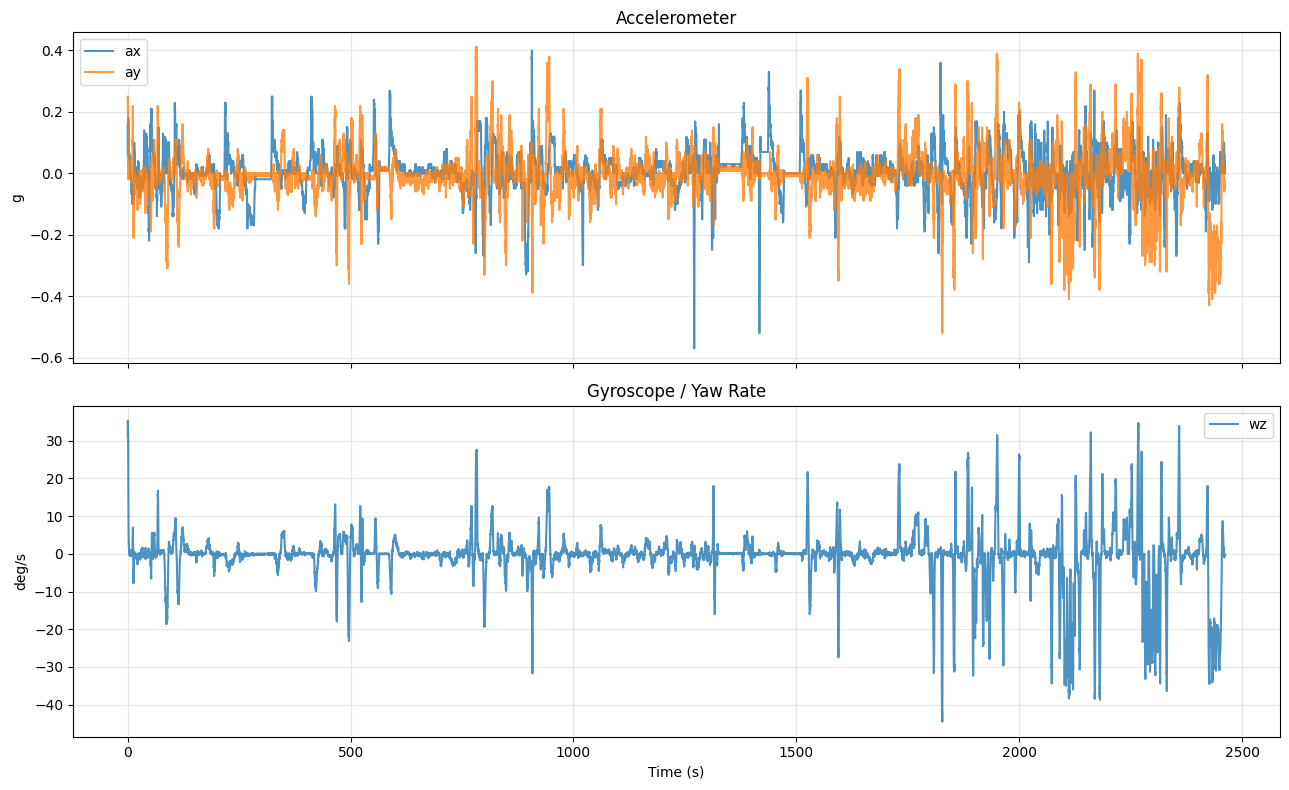

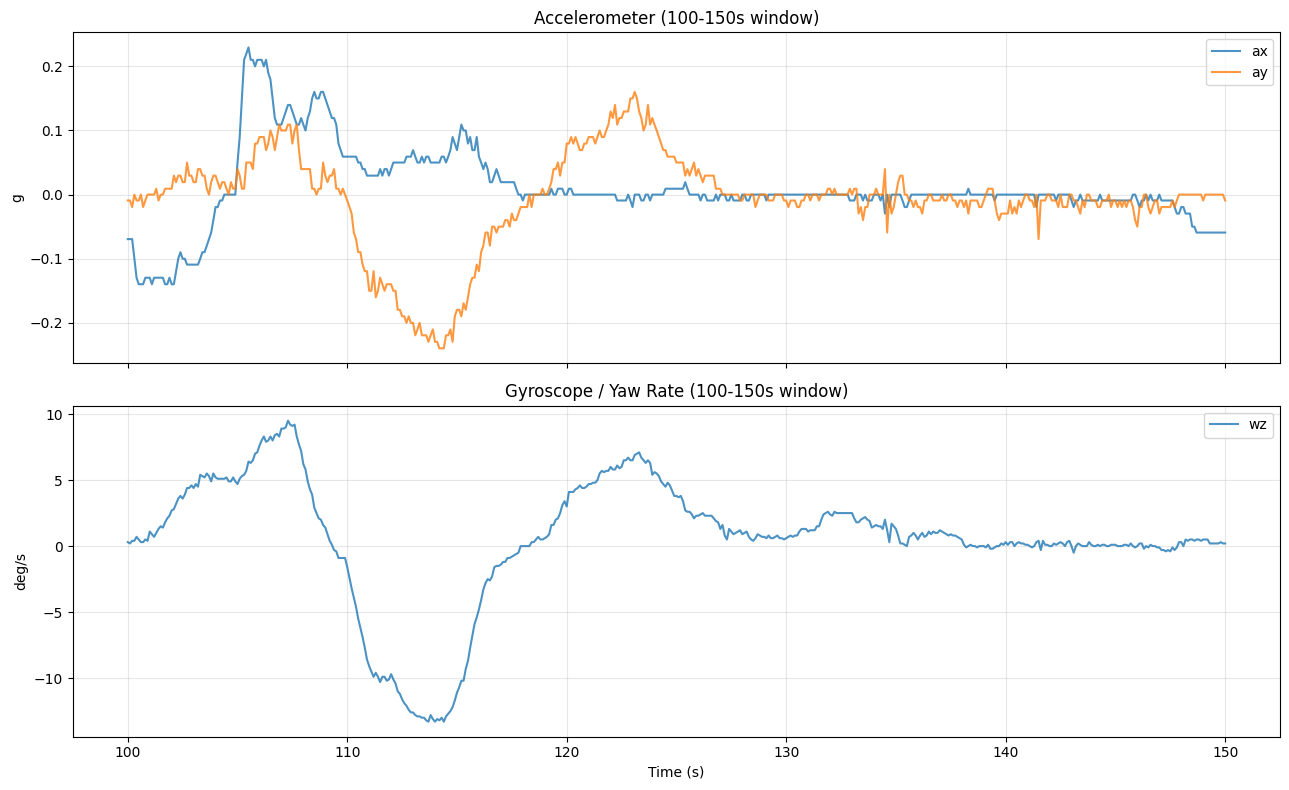

No gravity columns in this file -- skip this check (expected for vehicle-ECU files).
Wheel speed stats (rad/sec):
           wheel_fl      wheel_fr      wheel_rl      wheel_rr
count  24621.000000  24621.000000  24621.000000  24621.000000
mean      38.240867     38.163440     38.157097     38.010516
std       21.782872     21.832007     21.789990     21.785138
min        0.000000      0.000000      0.000000      0.000000
25%       24.050000     23.689990     23.939990     23.550000
50%       39.470000     39.440000     39.399990     39.340000
75%       50.480000     50.429990     50.399990     50.289990
max       98.289990     98.110000     98.069990     97.800000
Actual recorded span: 2462.0 seconds
Expected span if continuous: 2462.1 seconds
Difference (likely gap time): -0.1 seconds

Looks continuous -- no major gap detected.


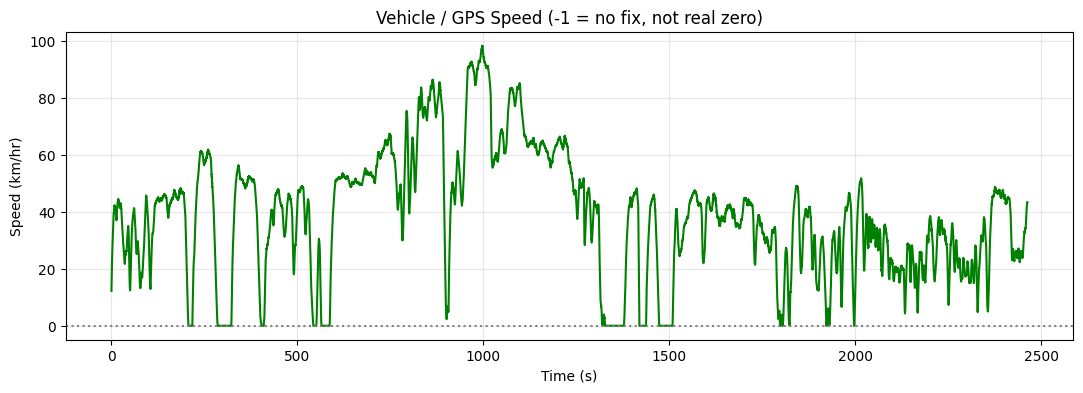

Number of 'no fix' samples (-1):
0 out of 24621
ZUPT preview only applies to phone files with ax/wz -- skipping.


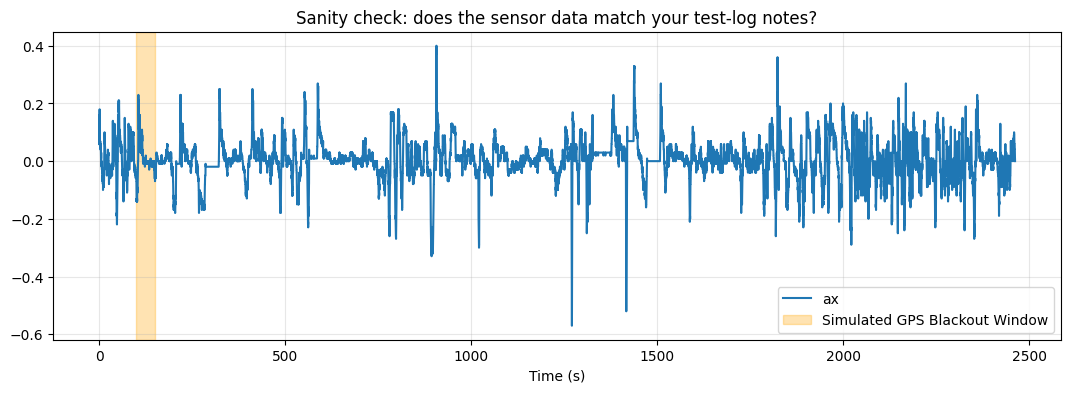

In [ ]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files
import io
from IPython.display import clear_output
import os

clear_output(wait=True)

# -------------------------------------------------------------
# 0. CONFIG -- keep this in sync with dead_reckoning_fixed.py /
# dead_reckoning_vehicle.py so the "blackout window" you're QA-checking
# here is the same one you're scoring error on in those scripts.
# -------------------------------------------------------------
WINDOW_START_S = 100
WINDOW_END_S = 150

print("Please upload an IO-VNBD CSV file (phone-side S-*.csv OR vehicle-ECU V-*.csv).")
uploaded = files.upload()

if uploaded:
    filename = next(iter(uploaded))
    print(f"Uploaded file: {filename}")
else:
    print("No file uploaded. Please upload a file to proceed.")
    filename = None

# Matches the window used in dead_reckoning_fixed.py / dead_reckoning_vehicle.py
# so diagnostics are looking at the same slice you're testing DR against.
WINDOW_START_S = 100
WINDOW_END_S = 150

# Same ZUPT thresholds as dead_reckoning_fixed.py -- change both places together.
ACCEL_STD_THRESHOLD = 0.05
GYRO_THRESHOLD_RAD_S = 0.05
ZUPT_WINDOW_SAMPLES = 10


def load_data(filename_or_buffer):
    df = None
    try:
        if isinstance(filename_or_buffer, str) and filename_or_buffer in uploaded:
            df = pd.read_csv(io.BytesIO(uploaded[filename_or_buffer]), encoding='latin1')
        elif isinstance(filename_or_buffer, str) and os.path.exists(filename_or_buffer):
            df = pd.read_csv(filename_or_buffer, encoding='latin1')
        else:
            raise ValueError("Invalid filename or buffer provided to load_data.")
    except UnicodeDecodeError:
        print("UnicodeDecodeError with latin1, trying ISO-8859-1")
        if isinstance(filename_or_buffer, str) and filename_or_buffer in uploaded:
            df = pd.read_csv(io.BytesIO(uploaded[filename_or_buffer]), encoding='ISO-8859-1')
        elif isinstance(filename_or_buffer, str) and os.path.exists(filename_or_buffer):
            df = pd.read_csv(filename_or_buffer, encoding='ISO-8859-1')
        else:
            raise ValueError("Invalid filename or buffer provided to load_data.")

    df.columns = df.columns.str.strip()
    is_vehicle_file = 'Wheel Speed Front Left (rad/sec)' in df.columns

    if is_vehicle_file:
        file_type = 'vehicle'
        column_mapping = {
            'Time Since Start of Day (seconds)': 'time_s',
            'Latitude (degrees)': 'lat',
            'Longitude (degrees)': 'lon',
            'Indicated Vehicle Speed (km/hr)': 'speed',
            'Indicated Longitudinal Acceleration (g)': 'ax',
            'Indicated Lateral Acceleration (g)': 'ay',
            'Yaw Rate (deg/sec)': 'wz',
            'Wheel Speed Front Left (rad/sec)': 'wheel_fl',
            'Wheel Speed Front Right (rad/sec)': 'wheel_fr',
            'Wheel Speed Rear Left (rad/sec)': 'wheel_rl',
            'Wheel Speed Rear Right (rad/sec)': 'wheel_rr',
            'Steering Angle (degrees)': 'steering_angle',
        }
    else:
        file_type = 'phone'
        column_mapping = {
            'TIME SINCE START (ms)': 'time_ms',
            'ACCELEROMETER X (m/s\u00b2)': 'ax',
            'ACCELEROMETER Y (m/s\u00b2)': 'ay',
            'ACCELEROMETER Z (m/s\u00b2)': 'az',
            'GRAVITY X (m/s\u00b2)': 'gx',
            'GRAVITY Y (m/s\u00b2)': 'gy',
            'GRAVITY Z (m/s\u00b2)': 'gz',
            'GYROSCOPE Yaw (rad/s)': 'wz',
            'GYROSCOPE Pitch (rad/s)': 'wy',
            'GYROSCOPE Roll (rad/s)': 'wx',
            'GPS SPEED (Kmh)': 'speed',
        }

    existing_columns = {k: v for k, v in column_mapping.items() if k in df.columns}
    df.rename(columns=existing_columns, inplace=True)

    print(f"Detected file type: {file_type}")
    print("Mapped Columns found:", list(df.columns))
    print("Number of rows:", len(df))
    return df, file_type


def add_time_column(df, file_type):
    if file_type == 'vehicle' and 'time_s' in df.columns:
        df['t_sec'] = pd.to_numeric(df['time_s'], errors='coerce')
        df['t_sec'] = df['t_sec'] - df['t_sec'].iloc[0]
    elif file_type == 'phone' and 'time_ms' in df.columns:
        df['t_sec'] = pd.to_numeric(df['time_ms'], errors='coerce') / 1000.0
        df['t_sec'] = df['t_sec'] - df['t_sec'].iloc[0]
    else:
        sampling_rate = 10
        df['t_sec'] = df.index / sampling_rate

    print("Calculated recording duration (seconds):", df['t_sec'].iloc[-1])
    return df


def check_sampling_rate(df):
    if 't_sec' not in df.columns:
        print("Error: 't_sec' column not found. Cannot check sampling rate.")
        return None

    time_diffs = df['t_sec'].diff()
    median_interval = time_diffs.median()
    print(f"Median sample interval: {median_interval:.4f} seconds")
    print(f"Estimated sampling rate: {1/median_interval:.1f} Hz")
    print()

    max_gap = time_diffs.max()
    max_gap_time = df['t_sec'].iloc[time_diffs.idxmax()]
    print(f"Biggest gap in recording: {max_gap:.3f} seconds, occurring at t={max_gap_time:.1f}s")
    print("(If this is much bigger than your median interval above, that's a dropout -- note it in your test log.)")

    return median_interval


def plot_accel_gyro(df, file_type, window=None):
    dfp = df
    title_suffix = ''
    if window is not None:
        dfp = df.loc[(df['t_sec'] >= window[0]) & (df['t_sec'] <= window[1])]
        title_suffix = f' ({window[0]}-{window[1]}s window)'

    accel_cols_to_plot = [col for col in ['ax', 'ay', 'az'] if col in dfp.columns]
    gyro_cols_to_plot = [col for col in ['wx', 'wy', 'wz'] if col in dfp.columns]

    if not accel_cols_to_plot and not gyro_cols_to_plot:
        print("Error: No accelerometer or gyroscope columns available to plot.")
        return

    accel_unit = 'g' if file_type == 'vehicle' else 'm/s\u00b2'
    gyro_unit = 'deg/s' if file_type == 'vehicle' else 'rad/s'

    fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

    if accel_cols_to_plot:
        for col in accel_cols_to_plot:
            axes[0].plot(dfp['t_sec'], dfp[col], label=col, alpha=0.8)
        axes[0].set_title('Accelerometer' + title_suffix)
        axes[0].set_ylabel(accel_unit)
        axes[0].legend()
        axes[0].grid(alpha=0.3)
    else:
        axes[0].set_visible(False)

    if gyro_cols_to_plot:
        for col in gyro_cols_to_plot:
            axes[1].plot(dfp['t_sec'], dfp[col], label=col, alpha=0.8)
        axes[1].set_title('Gyroscope / Yaw Rate' + title_suffix)
        axes[1].set_ylabel(gyro_unit)
        axes[1].set_xlabel('Time (s)')
        axes[1].legend()
        axes[1].grid(alpha=0.3)
    else:
        axes[1].set_visible(False)

    plt.tight_layout()
    plt.show()


def check_raw_accel(df):
    if 'gx' in df.columns and 'gy' in df.columns and 'gz' in df.columns:
        g_magnitude = (df['gx'] ** 2 + df['gy'] ** 2 + df['gz'] ** 2) ** 0.5
        print("Gravity vector magnitude stats (should hover near 9.8 m/s\u00b2):")
        print(g_magnitude.describe())
    else:
        print("No gravity columns in this file -- skip this check (expected for vehicle-ECU files).")


def check_wheel_speeds(df):
    wheel_cols = [c for c in ['wheel_fl', 'wheel_fr', 'wheel_rl', 'wheel_rr'] if c in df.columns]
    if not wheel_cols:
        print("No wheel speed columns in this file -- skip this check (expected for phone files).")
        return
    print("Wheel speed stats (rad/sec):")
    print(df[wheel_cols].describe())


def check_hidden_gaps(df, median_interval):
    if 't_sec' not in df.columns or median_interval is None:
        print("Cannot check hidden gaps due to missing 't_sec' column or median_interval.")
        return

    expected_duration = len(df) * median_interval
    actual_duration = df['t_sec'].iloc[-1]

    print(f"Actual recorded span: {actual_duration:.1f} seconds")
    print(f"Expected span if continuous: {expected_duration:.1f} seconds")
    print(f"Difference (likely gap time): {actual_duration - expected_duration:.1f} seconds")

    if actual_duration - expected_duration > 5:
        print()
        print("WARNING: There's likely a significant gap in this recording (screen lock / app backgrounded).")
        print("Check the 'biggest gap' value above to find exactly when it happened.")
    else:
        print()
        print("Looks continuous -- no major gap detected.")


def plot_gps_speed(df):
    if 'speed' not in df.columns or 't_sec' not in df.columns:
        print("No 'speed' or 't_sec' column in this file -- skip this check.")
        return

    plt.figure(figsize=(13, 4))
    plt.plot(df['t_sec'], df['speed'], color='green')
    plt.axhline(0, color='gray', linestyle=':')
    plt.title('Vehicle / GPS Speed (-1 = no fix, not real zero)')
    plt.xlabel('Time (s)')
    plt.ylabel('Speed (km/hr)')
    plt.grid(alpha=0.3)
    plt.show()

    print("Number of 'no fix' samples (-1):")
    print((df['speed'] == -1).sum(), "out of", len(df))


def preview_zupt_thresholds(df, file_type, window):
    # NEW: only meaningful for the phone file, since ZUPT in
    # dead_reckoning_fixed.py runs on the 'ax' + 'wz' inertial signal.
    # Shows which samples in the window WOULD be treated as stationary
    # at the current thresholds, so you can tune before running the
    # full dead-reckoning script.
    if file_type != 'phone' or 'ax' not in df.columns or 'wz' not in df.columns:
        print("ZUPT preview only applies to phone files with ax/wz -- skipping.")
        return

    dfw = df.loc[(df['t_sec'] >= window[0]) & (df['t_sec'] <= window[1])].reset_index(drop=True)
    if len(dfw) < 5:
        print("Not enough samples in window for ZUPT preview.")
        return

    dfw['ax_rolling_std'] = dfw['ax'].rolling(ZUPT_WINDOW_SAMPLES, center=True, min_periods=1).std().fillna(0)
    dfw['is_stationary'] = (dfw['ax_rolling_std'] < ACCEL_STD_THRESHOLD) & (dfw['wz'].abs() < GYRO_THRESHOLD_RAD_S)

    print(f"ZUPT preview over {window[0]}-{window[1]}s: {dfw['is_stationary'].sum()} / {len(dfw)} samples "
          f"flagged stationary (thresholds: accel_std<{ACCEL_STD_THRESHOLD}, |gyro|<{GYRO_THRESHOLD_RAD_S}).")
    print("If this is 0 across a window you know includes a stop, loosen the thresholds.")
    print("If this is nearly all samples even while moving, tighten them.")


def mark_known_event(df, event_start, event_end, event_label="Known event (from test log)"):
    if 't_sec' not in df.columns or 'ax' not in df.columns:
        print("Cannot mark known event due to missing 't_sec' or 'ax' column.")
        return

    plt.figure(figsize=(13, 4))
    plt.plot(df['t_sec'], df['ax'], label='ax')
    plt.axvspan(event_start, event_end, color='orange', alpha=0.3, label=event_label)
    plt.legend()
    plt.title('Sanity check: does the sensor data match your test-log notes?')
    plt.xlabel('Time (s)')
    plt.grid(alpha=0.3)
    plt.show()


def run_analysis(filename_to_analyze):
    if filename_to_analyze is None:
        print("No file to analyze.")
        return

    try:
        df, file_type = load_data(filename_to_analyze)
        df = add_time_column(df, file_type)

        median_interval = check_sampling_rate(df)
        plot_accel_gyro(df, file_type)                          # full recording
        plot_accel_gyro(df, file_type, window=(WINDOW_START_S, WINDOW_END_S))  # just the test window
        check_raw_accel(df)
        check_wheel_speeds(df)
        check_hidden_gaps(df, median_interval)
        plot_gps_speed(df)
        preview_zupt_thresholds(df, file_type, (WINDOW_START_S, WINDOW_END_S))

        mark_known_event(df, WINDOW_START_S, WINDOW_END_S, "Simulated GPS Blackout Window")

    except Exception as e:
        print(f"An error occurred during analysis: {e}")


run_analysis(filename)